In [1]:
import sys
sys.path.insert(0, '../')
sys.path.insert(1, '../../')
from build_config import ALL_SEASONS, COMPETITIONS, CURRENT_SEASON, INPUT_CSV_PATHS, TARGET_RANGES
from const import REPO_PATH, RAW_DATA_PATH, PROCESSED_DATA_PATH, MODELS_PATH
from fbref_const import URLs, TARGET_COLUMNS

from src.data.match_data_processing import process_match_target_var, process_match_other_var
from src.feature.feature_encoders import TeamEncoder, TeamLagFeatureGenerator, PreviousSeasonTeamAverager, TeamRestDaysCalculator, TeamLagTargetFeature

import pandas as pd
import os
import numpy as np
import mlflow
import joblib
import tempfile
import os

from build_utils import *

In [2]:
key_columns=['date', 'home', 'away']

In [3]:
team_encoder_path = f"{MODELS_PATH}/data_processors/{COMPETITIONS[0]}/team_encoder.pkl"
encoder = TeamEncoder.load(team_encoder_path)

In [4]:
seasons=sorted(ALL_SEASONS)

In [5]:
test_dict=dict((k, pd.read_csv(f'{REPO_PATH}/{INPUT_CSV_PATHS[k]}')) for k in COMPETITIONS)

In [6]:
all_features_dict={}
for competition in COMPETITIONS:
    if competition not in test_dict:
        continue
    test_df = test_dict[competition]
    team_encoder_path = f"{MODELS_PATH}/data_processors/{competition}/team_encoder.pkl"
    season_dfs_dict = {season: pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_data_df.csv") for season in seasons}
    target_dfs = [pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_target_df.csv") for season in seasons]
    # TeamEncoder features
    encoder = TeamEncoder.load(team_encoder_path)
    team_encoder_features = encoder.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagFeatureGenerator features
    lag_feature_generator = TeamLagFeatureGenerator(lookback=5)
    team_lag_features = lag_feature_generator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # PreviousSeasonTeamAverager features
    prev_season_averager = PreviousSeasonTeamAverager(decay_factor=1, date_col='date', home_col='home', away_col='away')
    prev_season_features = prev_season_averager.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamRestDaysCalculator features
    rest_days_calculator = TeamRestDaysCalculator()
    rest_days_features = rest_days_calculator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagTargetFeature features
    lag_target_generator = TeamLagTargetFeature(lookback=5)
    lag_target_features = lag_target_generator.transform_spot(season_dfs_dict, target_dfs, test_df).reset_index(drop=True)

    # Merge all features on home, away, date
    from functools import reduce
    feature_dfs = [team_encoder_features, team_lag_features, prev_season_features, rest_days_features, lag_target_features]
    all_features = reduce(lambda left, right: pd.merge(left, right, on=['home', 'away', 'date'], how='outer'), feature_dfs)
    
    scaler = joblib.load(os.path.join(f"{MODELS_PATH}/data_processors/{competition}", 'standard_scaler.pkl'))
    all_features[scaler.feature_names_in_] = scaler.transform(all_features[scaler.feature_names_in_])

    all_features_dict[competition] = all_features.copy().fillna(-1)

In [7]:
train_features=pd.read_csv(f"{REPO_PATH}/data/features/premier_league/all_combined_features_2017-24.csv")
train_features['date'] = pd.to_datetime(train_features['date'])
train_features = train_features.merge(all_features_dict['premier_league'][['home', 'away', 'date']], on=['home', 'away', 'date'], how='right').fillna(-1)

for competition, df in all_features_dict.items():
    all_features_dict[competition] = df[train_features.columns]

In [8]:
# Compare train_features and all_features_dict['premier_league'] (excluding home, away, date)
tf_values = train_features.drop(columns=['home', 'away', 'date']).values
af_values = all_features_dict['premier_league'].drop(columns=['home', 'away', 'date']).values

# Find where they differ
diff_mask = 1-np.isclose(tf_values, af_values)
diff_indices = np.argwhere(diff_mask)
print(f"Number of differing values: {diff_indices.shape[0]}")
print("First 10 differences:")
train_feature_cols = train_features.drop(columns=['home', 'away', 'date']).columns.tolist()
all_feature_cols = all_features_dict['premier_league'].drop(columns=['home', 'away', 'date']).columns.tolist()
for idx, (row, col) in enumerate(diff_indices[:10]):
    home = train_features.iloc[row]['home']
    away = train_features.iloc[row]['away']
    date = train_features.iloc[row]['date']
    tf_val = tf_values[row, col]
    af_val = af_values[row, col]
    col_name = train_feature_cols[col]
    col_name_af = all_feature_cols[col]

    print(f"Row {row}, Column '{col_name}, {col_name_af}': home={home}, away={away}, date={date}, train_features={tf_val}, all_features_dict={af_val}")

Number of differing values: 25486
First 10 differences:
Row 0, Column 'encoded_home_Arsenal, encoded_home_Arsenal': home=Aston Villa, away=Newcastle Utd, date=2025-08-16 00:00:00, train_features=-1.0, all_features_dict=0.0
Row 0, Column 'encoded_home_Bournemouth, encoded_home_Bournemouth': home=Aston Villa, away=Newcastle Utd, date=2025-08-16 00:00:00, train_features=-1.0, all_features_dict=0.0
Row 0, Column 'encoded_home_Brighton, encoded_home_Brighton': home=Aston Villa, away=Newcastle Utd, date=2025-08-16 00:00:00, train_features=-1.0, all_features_dict=0.0
Row 0, Column 'encoded_home_Burnley, encoded_home_Burnley': home=Aston Villa, away=Newcastle Utd, date=2025-08-16 00:00:00, train_features=-1.0, all_features_dict=0.0
Row 0, Column 'encoded_home_Chelsea, encoded_home_Chelsea': home=Aston Villa, away=Newcastle Utd, date=2025-08-16 00:00:00, train_features=-1.0, all_features_dict=0.0
Row 0, Column 'encoded_home_Crystal Palace, encoded_home_Crystal Palace': home=Aston Villa, away=Ne

In [9]:
model_dict={
    'premier_league': {
        'away_goals':{
            'run_id': '52ba3bb17f904629bddb9db2c8d19212',
            'artifact_path': 'model',
        },
        'home_goals':{
            'run_id': 'a1f26bb7bbf942f5873fc47000527aff',
            'artifact_path': 'model',
        },
    }
}

In [10]:
def load_joblib_model_from_mlflow(run_id, artifact_path, tracking_uri=None):
    """
    Fetch and load a joblib-dumped model from MLflow given experiment_id, run_id, and artifact_path.
    Optionally specify the MLflow tracking URI.
    Returns the loaded model.
    """
    if tracking_uri is not None:
        mlflow.set_tracking_uri(tracking_uri)
    client = mlflow.tracking.MlflowClient()
    # Download artifact to a temporary directory
    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
        # Find the first .joblib file in the artifact directory
        for root, _, files in os.walk(local_path):
            for file in files:
                if file.endswith('.joblib'):
                    model_path = os.path.join(root, file)
                    return joblib.load(model_path)
        raise FileNotFoundError("No .joblib model file found in the artifact path.")


In [11]:
predictions={}

In [12]:
for competition in COMPETITIONS:
    predictions[competition] = {}
    for target_name in TARGET_RANGES:
        model = load_joblib_model_from_mlflow(model_dict[competition][target_name]['run_id'],
                                                model_dict[competition][target_name]['artifact_path'],
                                                f'{REPO_PATH}/mlflow')
        prediction = model.predict_proba(all_features_dict[competition].drop(columns=key_columns))
        prediction = pd.DataFrame(prediction, columns=list(range(TARGET_RANGES[target_name][0], TARGET_RANGES[target_name][1]+1))+['other'])
        predictions[competition][target_name]=prediction

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Add home, away, date columns from test_dict to each predictions DataFrame
for competition in predictions:
    test_rows = all_features_dict[competition][['home', 'away', 'date']].reset_index(drop=True)
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        # Prepend home, away, date columns
        df = pd.concat([test_rows, df.reset_index(drop=True)], axis=1)
        predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [14]:
predictions['premier_league']['home_goals']

,home,away,date,0,1,2,3,4,5,other
0,Aston Villa,Newcastle Utd,2025-08-16,0.169594,0.412606,0.265822,0.082714,0.051847,0.013213,0.004205
1,Brighton,Fulham,2025-08-16,0.161537,0.409450,0.212972,0.129998,0.045798,0.037510,0.002734
2,Chelsea,Crystal Palace,2025-08-17,0.286782,0.247598,0.280856,0.108263,0.058750,0.013339,0.004411
3,Leeds United,Everton,2025-08-18,0.245471,0.413129,0.227779,0.053271,0.051793,0.005397,0.003160
4,Liverpool,Bournemouth,2025-08-15,0.181459,0.359001,0.264395,0.086526,0.089219,0.017026,0.002374
5,Manchester Utd,Arsenal,2025-08-17,0.386541,0.264317,0.165853,0.141377,0.032922,0.006242,0.002748
6,Nott'ham Forest,Brentford,2025-08-17,0.228532,0.339064,0.277785,0.096390,0.036853,0.015471,0.005906
7,Sunderland,West Ham,2025-08-16,0.396297,0.268029,0.197032,0.097395,0.028451,0.010259,0.002536
8,Tottenham,Burnley,2025-08-16,0.130317,0.274360,0.318325,0.133527,0.087203,0.053316,0.002951
9,Wolves,Manchester City,2025-08-16,0.238967,0.241915,0.377444,0.093129,0.032966,0.012524,0.003054


In [15]:
predictions['premier_league']['away_goals']

,home,away,date,0,1,2,3,4,5,6,other
0,Aston Villa,Newcastle Utd,2025-08-16,0.387707,0.263927,0.172987,0.091720,0.060191,0.017111,0.002986,0.003371
1,Brighton,Fulham,2025-08-16,0.284454,0.321937,0.276340,0.073306,0.033225,0.005421,0.003768,0.001549
2,Chelsea,Crystal Palace,2025-08-17,0.221588,0.425551,0.216858,0.088020,0.042203,0.003185,0.001351,0.001244
3,Leeds United,Everton,2025-08-18,0.231460,0.241421,0.276923,0.155625,0.030426,0.059049,0.002705,0.002392
4,Liverpool,Bournemouth,2025-08-15,0.147483,0.380340,0.283318,0.156221,0.022058,0.006936,0.001979,0.001666
5,Manchester Utd,Arsenal,2025-08-17,0.247577,0.495339,0.126680,0.104077,0.016501,0.004556,0.003051,0.002219
6,Nott'ham Forest,Brentford,2025-08-17,0.292241,0.282766,0.266803,0.135093,0.012249,0.003945,0.003342,0.003560
7,Sunderland,West Ham,2025-08-16,0.151951,0.379168,0.242569,0.165080,0.019228,0.037851,0.002268,0.001885
8,Tottenham,Burnley,2025-08-16,0.296312,0.330765,0.250127,0.073637,0.029290,0.014142,0.002436,0.003291
9,Wolves,Manchester City,2025-08-16,0.261334,0.335492,0.257591,0.114578,0.019898,0.004858,0.004594,0.001656


In [16]:
# Convert all column names in predictions DataFrames to string type
for competition in predictions:
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        df.columns = [str(col) for col in df.columns]
        predictions[competition][target_name] = df

In [17]:
# Rename columns and update values in predictions DataFrames for each competition and target
import copy
acc_predictions = copy.deepcopy(predictions)
for competition in acc_predictions:
    for target_name in acc_predictions[competition]:
        df = acc_predictions[competition][target_name]
        cols = df.columns.tolist()
        # Only rename and update non-metadata columns (assume first three are home, away, date)
        meta_cols = ['home', 'away', 'date']
        feature_cols = cols[3:]
        # Rename columns: first becomes lte_{original}, others become gt_{previous}
        new_cols = meta_cols.copy()
        if feature_cols:
            new_cols.append(f"lte_{feature_cols[0]}")
            for i in range(1, len(feature_cols)):
                new_cols.append(f"gt_{feature_cols[i-1]}")
        # Update values: first feature column stays, others become sum of itself and all to the right
        arr = df[feature_cols].values.copy() if feature_cols else None
        if arr is not None and arr.shape[1] > 0:
            for i in range(1, arr.shape[1]):
                arr[:, i] = arr[:, i:].sum(axis=1)
            df = pd.concat([df[meta_cols].reset_index(drop=True), pd.DataFrame(arr, columns=new_cols[3:])], axis=1)
            df.columns = new_cols
            acc_predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [18]:
acc_predictions['premier_league']['home_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5
0,Aston Villa,Newcastle Utd,2025-08-16,0.169594,0.830406,0.417800,0.151979,0.069265,0.017418,0.004205
1,Brighton,Fulham,2025-08-16,0.161537,0.838463,0.429013,0.216041,0.086043,0.040245,0.002734
2,Chelsea,Crystal Palace,2025-08-17,0.286782,0.713218,0.465619,0.184764,0.076501,0.017751,0.004411
3,Leeds United,Everton,2025-08-18,0.245471,0.754529,0.341400,0.113621,0.060350,0.008557,0.003160
4,Liverpool,Bournemouth,2025-08-15,0.181459,0.818541,0.459539,0.195144,0.108619,0.019400,0.002374
5,Manchester Utd,Arsenal,2025-08-17,0.386541,0.613459,0.349142,0.183289,0.041913,0.008990,0.002748
6,Nott'ham Forest,Brentford,2025-08-17,0.228532,0.771468,0.432404,0.154620,0.058230,0.021377,0.005906
7,Sunderland,West Ham,2025-08-16,0.396297,0.603703,0.335674,0.138642,0.041247,0.012795,0.002536
8,Tottenham,Burnley,2025-08-16,0.130317,0.869683,0.595323,0.276998,0.143471,0.056267,0.002951
9,Wolves,Manchester City,2025-08-16,0.238967,0.761033,0.519118,0.141673,0.048545,0.015578,0.003054


In [19]:
acc_predictions['premier_league']['away_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5,gt_6
0,Aston Villa,Newcastle Utd,2025-08-16,0.387707,0.612293,0.348366,0.175379,0.083658,0.023468,0.006356,0.003371
1,Brighton,Fulham,2025-08-16,0.284454,0.715546,0.393608,0.117269,0.043962,0.010738,0.005317,0.001549
2,Chelsea,Crystal Palace,2025-08-17,0.221588,0.778412,0.352861,0.136003,0.047983,0.005780,0.002595,0.001244
3,Leeds United,Everton,2025-08-18,0.231460,0.768540,0.527119,0.250197,0.094571,0.064145,0.005097,0.002392
4,Liverpool,Bournemouth,2025-08-15,0.147483,0.852517,0.472177,0.188860,0.032639,0.010581,0.003645,0.001666
5,Manchester Utd,Arsenal,2025-08-17,0.247577,0.752423,0.257084,0.130405,0.026328,0.009827,0.005271,0.002219
6,Nott'ham Forest,Brentford,2025-08-17,0.292241,0.707759,0.424993,0.158189,0.023097,0.010848,0.006903,0.003560
7,Sunderland,West Ham,2025-08-16,0.151951,0.848049,0.468881,0.226312,0.061232,0.042004,0.004154,0.001885
8,Tottenham,Burnley,2025-08-16,0.296312,0.703688,0.372923,0.122796,0.049159,0.019869,0.005727,0.003291
9,Wolves,Manchester City,2025-08-16,0.261334,0.738666,0.403174,0.145584,0.031006,0.011108,0.006250,0.001656


In [20]:
import matplotlib.pyplot as plt
import math

def plot_predictions_distribution(predictions, competition, target_name, max_plots=10):
    df = predictions[competition][target_name]
    meta_cols = ['home', 'away', 'date']
    prob_cols = [col for col in df.columns if col not in meta_cols]
    n_plots = min(len(df), max_plots)
    
    # Calculate optimal grid dimensions ensuring rows >= cols
    n_cols = math.floor(math.sqrt(n_plots))
    n_rows = math.ceil(n_plots / n_cols)
    
    # Adjust if rows < cols
    if n_rows < n_cols:
        n_rows, n_cols = n_cols, n_rows
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
    
    # Plot data
    for idx in range(n_plots):
        i, j = idx // n_cols, idx % n_cols
        row = df.iloc[idx]
        axes[i, j].bar(prob_cols, row[prob_cols])
        axes[i, j].set_ylabel('Probability')
        axes[i, j].set_title(f"{row['home']} vs\n{row['away']}\n({row['date']})")
        axes[i, j].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for idx in range(n_plots, n_rows * n_cols):
        i, j = idx // n_cols, idx % n_cols
        axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()


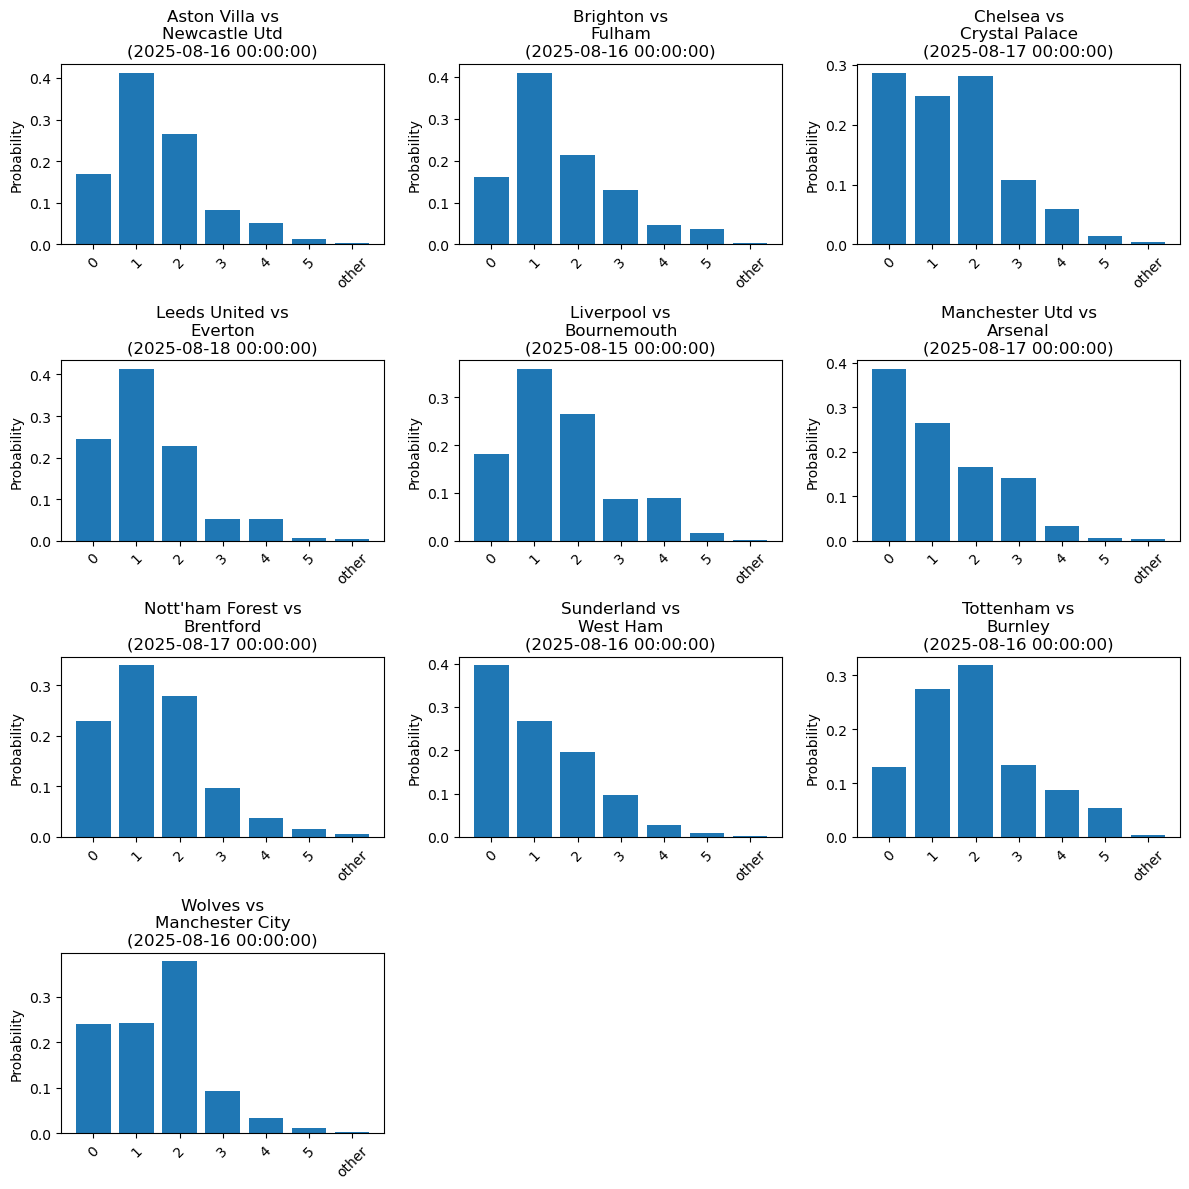

In [21]:
plot_predictions_distribution(predictions, 'premier_league', 'home_goals')

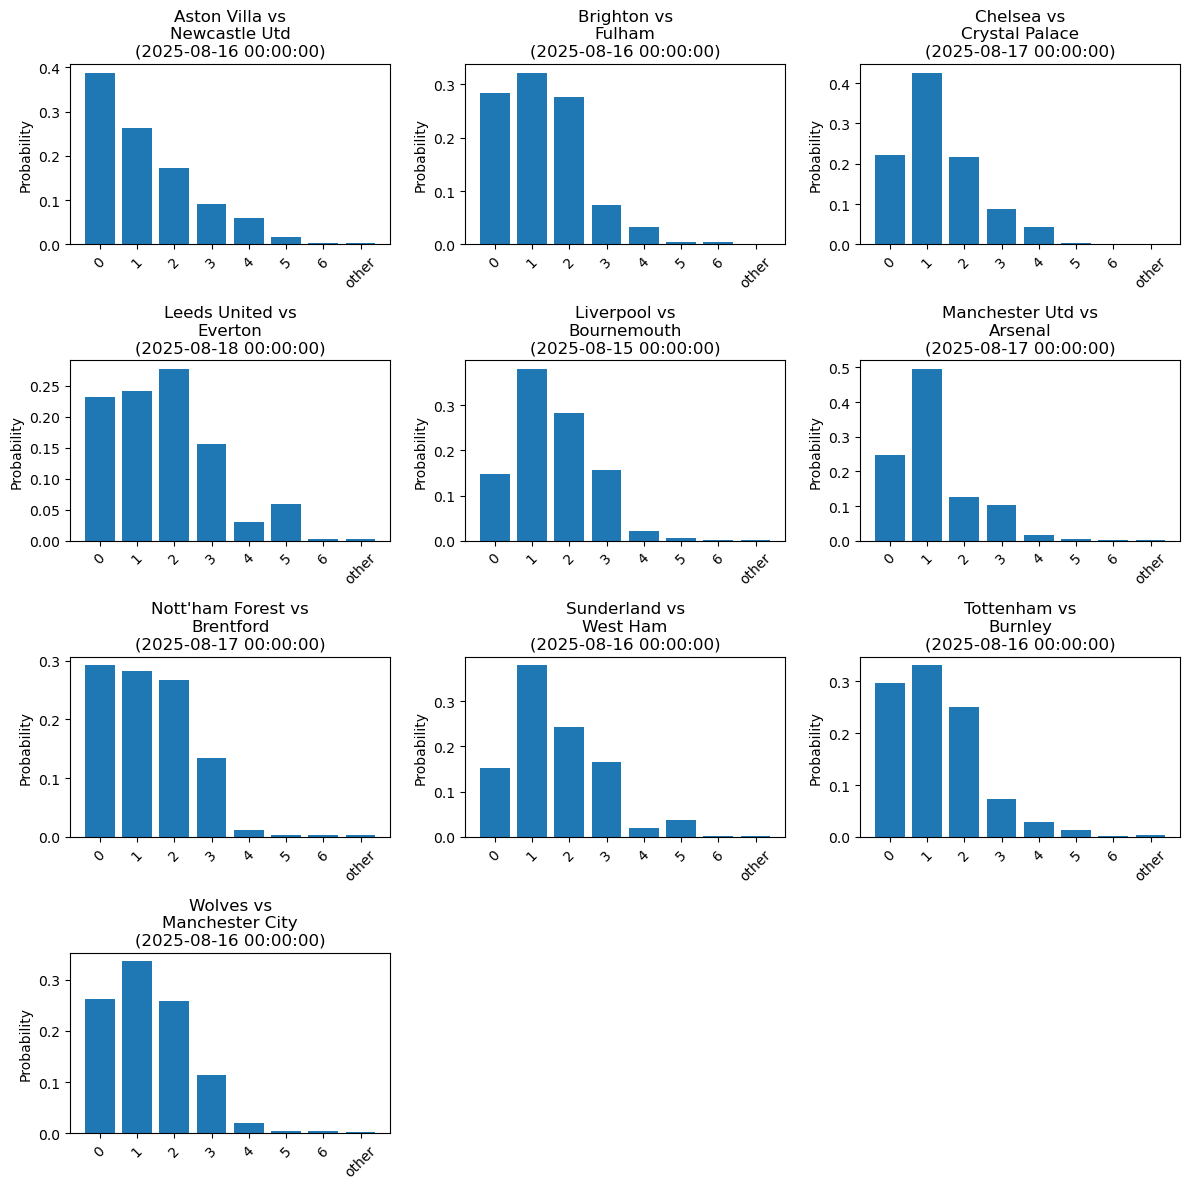

In [22]:
plot_predictions_distribution(predictions, 'premier_league', 'away_goals')